
===== TRAIN DATA =====


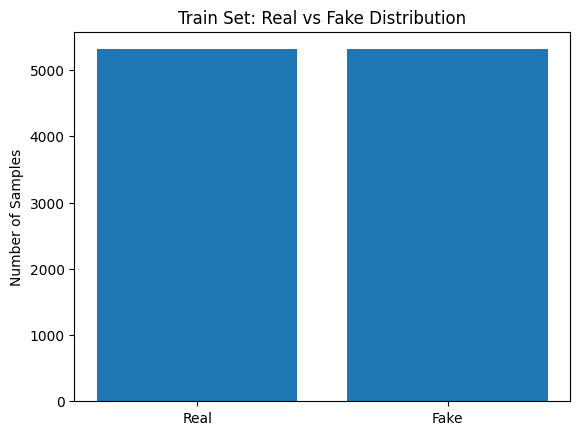


--- Fake distribution by attack type ---
unknown: 885
waveform_concatenation: 885
neural_vocoder_nonautoregressive: 885
neural_vocoder_autoregressive: 885
traditional_vocoder: 885
elevenlabs_fake: 886

===== TEST DATA =====


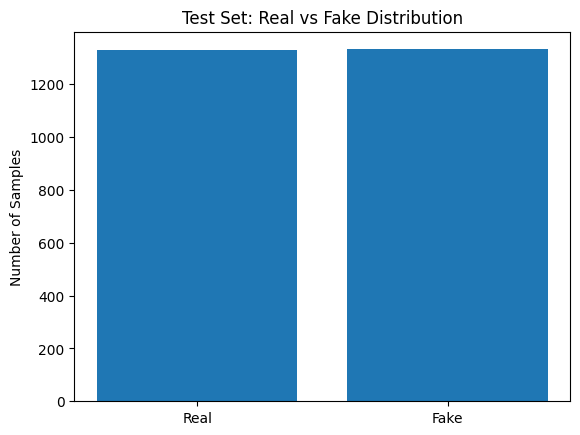


--- Fake distribution by attack type ---
unknown: 222
waveform_concatenation: 222
neural_vocoder_nonautoregressive: 222
neural_vocoder_autoregressive: 222
traditional_vocoder: 222
elevenlabs_fake: 222

===== TOTAL DATA =====
Total Real samples: 6643
Total Fake samples: 6643


In [ ]:
import os
import matplotlib.pyplot as plt

base_path = '/content/drive/MyDrive/dataset_split'

def analyze_split(split):
    print(f"\n===== {split.upper()} DATA =====")

    real_path = os.path.join(base_path, split, 'real')
    fake_path = os.path.join(base_path, split, 'fake')

    # ===== ספירת REAL =====
    real_count = len([
        f for f in os.listdir(real_path)
        if os.path.isfile(os.path.join(real_path, f))
    ])

    # ===== ספירת FAKE לפי סוג =====
    attack_counts = {}
    fake_total = 0

    for attack in os.listdir(fake_path):
        attack_folder = os.path.join(fake_path, attack)

        if os.path.isdir(attack_folder):
            count = len([
                f for f in os.listdir(attack_folder)
                if os.path.isfile(os.path.join(attack_folder, f))
            ])

            attack_counts[attack] = count
            fake_total += count

    # ===== גרף Real vs Fake =====
    plt.figure()
    plt.bar(['Real', 'Fake'], [real_count, fake_total])
    plt.title(f'{split.capitalize()} Set: Real vs Fake Distribution')
    plt.ylabel('Number of Samples')
    plt.show()

    # ===== הדפסה של סוגי זיופים =====
    print("\n--- Fake distribution by attack type ---")
    for attack, count in attack_counts.items():
        print(f"{attack}: {count}")

    return real_count, fake_total


# ===== הרצה =====
train_real, train_fake = analyze_split('train')
test_real, test_fake = analyze_split('test')

# ===== סכום כולל =====
total_real = train_real + test_real
total_fake = train_fake + test_fake

print("\n===== TOTAL DATA =====")
print(f"Total Real samples: {total_real}")
print(f"Total Fake samples: {total_fake}")

In [ ]:
import os
import librosa
import pandas as pd

base_path = "/content/drive/MyDrive/dataset_split"
audio_ext = (".wav", ".flac", ".mp3", ".m4a", ".ogg")

data_stats = []

def get_audio_info(folder, label, split):
    if not os.path.exists(folder):
        return

    files = [f for f in os.listdir(folder) if f.lower().endswith(audio_ext)]

    for f in files:
        path = os.path.join(folder, f)
        try:
            duration = librosa.get_duration(path=path)
            data_stats.append({
                "split": split,
                "סוג": label,
                "אורך_בשניות": duration
            })
        except:
            pass

for split in ["train", "test"]:
    real_dir = os.path.join(base_path, split, "real")
    fake_dir = os.path.join(base_path, split, "fake")

    get_audio_info(real_dir, "Real", split)

    if os.path.exists(fake_dir):
        for sub in os.listdir(fake_dir):
            sub_path = os.path.join(fake_dir, sub)
            if os.path.isdir(sub_path):
                get_audio_info(sub_path, f"Fake_{sub}", split)

df = pd.DataFrame(data_stats)

summary = df.groupby(["split", "סוג"]).agg(
    count=("אורך_בשניות", "count"),
    mean_duration=("אורך_בשניות", "mean"),
    min_duration=("אורך_בשניות", "min"),
    max_duration=("אורך_בשניות", "max")
).reset_index()

print(summary)

    split                                    סוג  count  mean_duration  \
0    test                   Fake_elevenlabs_fake    222       4.651592   
1    test     Fake_neural_vocoder_autoregressive    222       3.029434   
2    test  Fake_neural_vocoder_nonautoregressive    222       2.875100   
3    test               Fake_traditional_vocoder    222       3.115162   
4    test                           Fake_unknown    222       3.199699   
5    test            Fake_waveform_concatenation    222       2.454187   
6    test                                   Real   1329       3.494708   
7   train                   Fake_elevenlabs_fake    886       4.764275   
8   train     Fake_neural_vocoder_autoregressive    885       2.958091   
9   train  Fake_neural_vocoder_nonautoregressive    885       2.933626   
10  train               Fake_traditional_vocoder    885       3.099022   
11  train                           Fake_unknown    885       3.220990   
12  train            Fake_waveform_con

In [ ]:
print("\n--- ממוצע אורך לפי Real vs Fake ---")
real_fake_summary = df.copy()

# מאחדים את כל הזיופים ל-Fake
real_fake_summary["סוג_כללי"] = real_fake_summary["סוג"].apply(
    lambda x: "Fake" if "Fake" in x else "Real"
)

summary_rf = real_fake_summary.groupby("סוג_כללי")["אורך_בשניות"].agg(
    count="count",
    mean="mean",
    min="min",
    max="max"
)

print(summary_rf)



--- ממוצע אורך לפי Real vs Fake ---
          count      mean       min        max
סוג_כללי                                      
Fake       6643  3.235225  0.459375  76.272517
Real       6643  3.531913  0.519500  76.039500


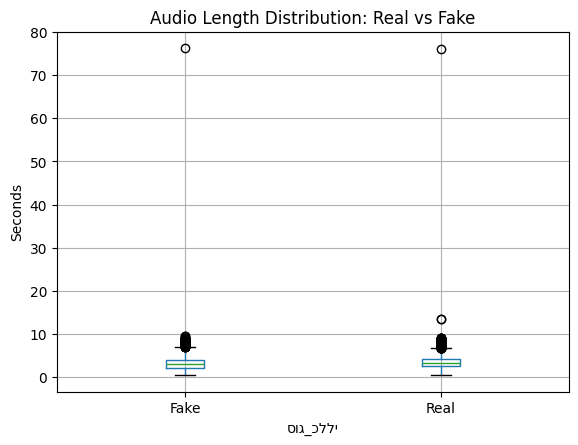

In [ ]:
import matplotlib.pyplot as plt

real_fake_summary.boxplot(column="אורך_בשניות", by="סוג_כללי")
plt.title("Audio Length Distribution: Real vs Fake")
plt.suptitle("")
plt.ylabel("Seconds")
plt.show()